## Talk to Me! LLM

So, the goal is simple, make the LLM be able to talk to us now

<img src="attachments/Screenshot 2026-03-06 at 5.35.43 PM.png" width=500>

There were 2 types of instructions (in the early days) to format these instructions to the LLMS, one called Alpaca prompty stype, and one called Phi-3 prompty style.

<img src="attachments/Screenshot 2026-03-06 at 5.56.32 PM.png" width=500>

The book uses Alpaca style, but I really wanna try if we can use the more modern Phi-3 style of prompting...

In [1]:
import json
import os
import requests


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


## Making Dataloaders

In [2]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [3]:
input_text = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(input_text, desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion 

### Response:
The correct spelling is 'Occasion.'


In [4]:
train_split = int(len(data) * 0.7)

train_data= data[:train_split]
test_data = data[train_split:]

print(len(train_data))
print(len(test_data))

770
330


In [5]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.input_length = []
        self.encoded_texts = []

        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text

            token_ids = tokenizer.encode(full_text)
            

            # if you are wondering why we are not turning them into pytorch tensors...
            # this will be done in the collate function
            self.encoded_texts.append(token_ids)
            self.input_length.append(len(tokenizer.encode(instruction_plus_input + '\n\n### Response:\n')))

    def __getitem__(self, index):
        return self.encoded_texts[index], self.input_length[index]

    def __len__(self):
        return len(self.encoded_texts)

This is a good start, we have turned the ids into tensors, but we have to store them in a python list.

Why? Because everything is variable lengthed in text, and tensors can't accept that.

So then the question comes, how do we somehow turn these variable lengthed text sequences into the same length? So then we can fill it in a tensor for parallel processing?

We have to 'dynamically' treat each batch differently, the idea goes as such:

<img src="attachments/Screenshot 2026-03-06 at 10.34.32 PM.png" width=500>

But, to dynamically treat each batch of data differently, this requires something called a collate function.

The idea is such that for each batch, it will have padding all the way such that the length of all sequences will be equal to the one with the longest length.

In [6]:
def collate_fn_sequence_pad(batch, pad_token_id=50256):

    max_len = max(len(item) for item in batch)
    inputs = []

    for item in batch:
        if len(item) <= max_len:
            inputs.append(torch.tensor(item + [pad_token_id] * (max_len - len(item))))
    
    inputs_tensor = torch.stack(inputs)
    return inputs_tensor

In [ ]:
inputs_1 = [0, 1, 2, 3, 4] 
inputs_2 = [5, 6] 
inputs_3 = [7, 8, 9] 
toy_batch = [inputs_1, inputs_2, inputs_3]

print(collate_fn_sequence_pad(toy_batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


Good! But that's just the inputs, we also need to do something similar to the outputs, except we need to 'shift' the outputs by a token. So we really need another function to do this.

In [8]:
def collate_fn_sequence_target(batch, pad_token_id=50256):

    inputs = []
    targets = []
    max_len = max(len(item) for item in batch)

    for item in batch:
        if len(item) <= max_len:
            padded = torch.tensor(item + [pad_token_id] * (max_len - len(item) + 1))
            inputs.append(padded[:-1].detach().clone())
            targets.append(padded[1:].detach().clone())

    inputs_tensor = torch.stack(inputs)
    targets_tensor = torch.stack(targets)

    return inputs_tensor, targets_tensor

In [ ]:
inputs, targets = collate_fn_sequence_target(toy_batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


Now, you might be asking this question, shouldn't the inputs of the model simply be the instructions? And the target be the desired response that we have? In just doing 1 token shift, how is that different from pre-training?

Well... it's what the book does in the main code sequence, I don't like that, so while we have achieved that effect with the above code, I'll change it in a bit.

Now, as part of our inputs and targets are padding, it's probably not a very smart idea that we want padding at outputs, however, in GPT 2's tokenizer, as there is no padding specific token, the best we can do is replace all supposed padding with -100.

In [ ]:
def collate_fn_final_maybe(batch, pad_token_id=50256, ignore_index=-100):
    
    inputs = []
    targets = []
    max_len = max(len(item) for item in batch)

    for item in batch:
        padded = item + [pad_token_id] + [pad_token_id] * (max_len - len(item))

        inputs_i = torch.tensor(padded[:-1])
        targets_i = torch.tensor(padded[1:])

        # padding for target tensor
        mask = targets_i == pad_token_id
        mask_indexes = torch.nonzero(mask, as_tuple=False).flatten()
        if len(mask_indexes) > 1:
            targets_i[mask_indexes[1:]] = ignore_index

        inputs.append(inputs_i)
        targets.append(targets_i)

    inputs_tensor = torch.stack(inputs)
    targets_tensor = torch.stack(targets)

    return inputs_tensor, targets_tensor


In [ ]:
inputs, targets = collate_fn_final_maybe(toy_batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In addition to masking padding tokens, it is also common practice to mask out the token IDs that correspond to the instructions of the task.

By masking out the LLM’s target token IDs corresponding to the instruction, the cross entropy loss is only computed for the generated response target IDs.

(That's originally part of the optional exercise, but I want to do that here)

<img src="attachments/Screenshot 2026-03-07 at 12.03.34 AM.png" width=500>

In [ ]:
def collate_fn_final(batch, pad_token_id=50256, ignore_index=-100):
    
    inputs = []
    targets = []
    max_len = max(len(token_ids) for token_ids, _ in batch) # this is our changed dataloader!

    for token_ids, prompt_length in batch:

        padded = token_ids + [pad_token_id] + [pad_token_id] * (max_len - len(token_ids))

        inputs_i = torch.tensor(padded[:-1])
        targets_i = torch.tensor(padded[1:])

        # prompt/instruction mask
        mask_1 = torch.arange(prompt_length - 1)

        # extra padding mask (skip first PAD target)
        pad_mask = targets_i == pad_token_id
        mask_2 = torch.nonzero(pad_mask, as_tuple=False).flatten()[1:]

        # combine both sets of positions
        mask_indexes = torch.cat((mask_1, mask_2))

        # apply mask if there is at least one index
        if mask_indexes.numel() > 0:
            targets_i[mask_indexes] = ignore_index

        inputs.append(inputs_i)
        targets.append(targets_i)

    inputs_tensor = torch.stack(inputs)
    targets_tensor = torch.stack(targets)

    return inputs_tensor, targets_tensor
        

In [7]:
inputs_1 = ([0, 1, 2, 3, 4], 2)
inputs_2 = ([5, 6], 2)
inputs_3 = ([7, 8, 9], 2)
toy_batch_2 = [inputs_1, inputs_2, inputs_3]

In [8]:
inputs, targets = collate_fn_final(toy_batch_2)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[ -100,     2,     3,     4, 50256],
        [ -100, 50256,  -100,  -100,  -100],
        [ -100,     9, 50256,  -100,  -100]])


In [9]:
from functools import partial
from torch.utils.data import DataLoader
import tiktoken


tokenizer = tiktoken.get_encoding("gpt2")
eot_id = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]
num_workers = 0
batch_size = 8
torch.manual_seed(42)

customized_collate_fn = partial(
    collate_fn_final,
    pad_token_id=eot_id,
    ignore_index=-100,
)

train_dataset = InstructionDataset(train_data, tokenizer)
test_dataset = InstructionDataset(test_data, tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)


test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)


As you can see, these are 'variable lengthed' packages, not fixed sizes

In [83]:
for i, (inputs, targets) in enumerate(train_loader):
    print(inputs.shape)
    print(targets.shape)
    print()
    if i > 5:
        break

torch.Size([8, 68])
torch.Size([8, 68])

torch.Size([8, 76])
torch.Size([8, 76])

torch.Size([8, 62])
torch.Size([8, 62])

torch.Size([8, 74])
torch.Size([8, 74])

torch.Size([8, 76])
torch.Size([8, 76])

torch.Size([8, 75])
torch.Size([8, 75])

torch.Size([8, 64])
torch.Size([8, 64])



## Loading Pre-trained Model

This is nothing new, we simply load our pre-trained model from our chapter 5 code (it's the downloaded GPT 2 model)

In [17]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [18]:
from previous_chapters import GPTModel


CHOOSE_MODEL = "gpt2-small (124M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
weights_path = "../5 Pre-training/gpt2-small-124M.pth"

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
model = GPTModel(BASE_CONFIG)
model.load_state_dict(torch.load(weights_path, weights_only=True))
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

## Training

There's... not much change to the code in this chapter, it's just god practice to tell yourself again how this training process works.

But it does raise a question, how do we evaluate how 'correct' our model's answers are? They are words, and there's no way for us to check 1000 reponseses to see if they are correct or not.

In [22]:
import time

torch.manual_seed(42) 
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=-100) # when we encoutner maksed indexes as targets, don't track gradients!
epochs = 5
eval_interval = 2

train_loss_list = []
test_loss_list = []
epoch_list = []

In [ ]:
start_time = time.time()


for epoch in range(epochs):

    train_loss = 0

    for inputs, targets in train_loader:
    
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = loss_fn(outputs.flatten(0, 1), targets.flatten())
        loss.backward()
        optimizer.step()

        train_loss += loss.item()


    if epoch % eval_interval == 0 or epoch == epochs - 1:

        model.eval()
        test_loss = 0

        with torch.no_grad():

            for inputs, targets in test_loader:

                outputs = model(inputs)
                loss = loss_fn(outputs.flatten(0, 1), targets.flatten())

                test_loss += loss.item()

        train_loss = train_loss / len(train_loader)
        test_loss = test_loss / len(test_loader)

        train_loss_list.append(train_loss)
        test_loss_list.append(test_loss)
        epoch_list.append(epoch)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Test Loss: {test_loss:.4f}"
        )

        model.train()


end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training time: {elapsed_time:.2f} seconds")


Epoch 1/5 | Train Loss: 1.3350 | Test Loss: 1.3221
Epoch 3/5 | Train Loss: 0.3931 | Test Loss: 1.5230
Epoch 5/5 | Train Loss: 0.1376 | Test Loss: 1.7332
Training time: 630.61 seconds


Uh... the text is a little broken, but else than that, don't worry about it!

In [24]:
PATH = 'GPT_instruct_weights.pth'
torch.save(model.state_dict(), PATH)

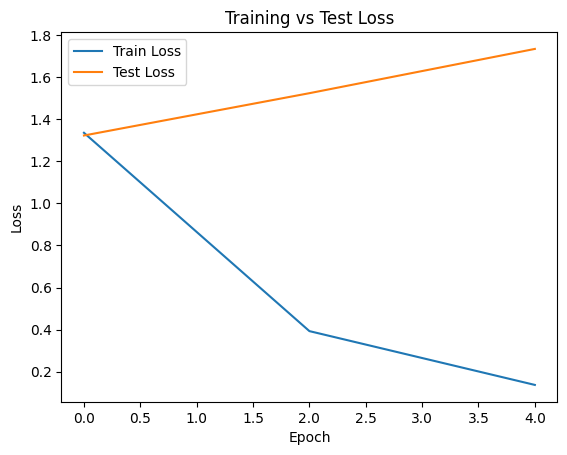

In [25]:
import matplotlib.pyplot as plt

# Loss plot
plt.figure()
plt.plot(epoch_list, train_loss_list, label="Train Loss")
plt.plot(epoch_list, test_loss_list, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.show()

Peculiar! The test loss is going up? Let's see how it actually fairs in real usage.

## Inspecting LLM Performance

Now, how does it do in actual responses? We will put the LLM generated response side by side to the desired response.

In [ ]:
from previous_chapters import GPTModel

model = GPTModel(BASE_CONFIG)  # same architecture as when training
state = torch.load("model.pt")
model.load_state_dict(state)
model.eval();

In [101]:
def generate_response(model, tokenizer, token_ids, prompt_len, max_new_tokens=120, top_k=20, temperature=1.5):

    model.eval()
    entry = torch.tensor(token_ids[:prompt_len]).unsqueeze(0)
    outputs = []

    with torch.no_grad():
        while len(outputs) < max_new_tokens:
            idx_cond = entry[:, -BASE_CONFIG["context_length"]:]
            logits = model(idx_cond)[:, -1, :]

            _, top_pos = torch.topk(logits, top_k, dim=-1)
            mask = torch.ones_like(logits, dtype=torch.bool)
            mask.scatter_(dim=-1, index=top_pos, value=False)
            logits = logits.masked_fill(mask, -torch.inf)

            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            id_next = torch.multinomial(probs, num_samples=1)

            next_token = id_next.item()
            if next_token == eot_id:
                break

            outputs.append(next_token)
            entry = torch.cat((entry, id_next), dim=-1)


    '''
    print(f"Input:\n{tokenizer.decode(token_ids[:prompt_len])}")
    print()
    print(f"Model Output:\n{tokenizer.decode(outputs)}")
    print()
    print(f"Desired Output:\n{tokenizer.decode(token_ids[prompt_len:])}")
    '''

    instruction_text = tokenizer.decode(token_ids[:prompt_len])
    model_text = tokenizer.decode(outputs)
    reference_text = tokenizer.decode(token_ids[prompt_len:])

    formatted_output = (
    f"Input:\n{instruction_text}\n\n"
    f"Model Output:\n{model_text}\n\n"
    f"Desired Output:\n{reference_text}"
    )

    return formatted_output, model_text

    


In [ ]:
token_ids, prompt_len = test_dataset[4]
out, _ = generate_response(model, tokenizer, token_ids, prompt_len)
out

Input:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Transform the following sentence to include an exclamation mark to show excitement.

### Input:
I won the lottery

### Response:


Model Output:
The exclamation mark shows great love.

Desired Output:
I won the lottery!


In [ ]:
token_ids, prompt_len = test_dataset[5]
out, _ = generate_response(model, tokenizer, token_ids, prompt_len)
out

Input:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the following sentence to use a simile: The wind howled through the night.

### Response:


Model Output:
The wind howled through the night.

Desired Output:
The wind howled through the night like a pack of wolves.


In [ ]:
token_ids, prompt_len = train_dataset[5]
out, _ = generate_response(model, tokenizer, token_ids, prompt_len)
out

Input:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Suggest a more formal synonym for "happy."

### Response:


Model Output:
A more formal synonym for "happy" is "joyful."

Desired Output:
A more formal synonym for "happy" is "content."


So, it's 'somewhat' working, as you can see from these examples, 1 is unrelated through the roof, 2 is doing it incorrectly, only 3 does it's job.

But now we have to turn to the question: How do we actually evalaute these LLMs? We judged these question's answers based on what we saw, but what if there's 10000 questions?

Sometimes there are a formal metric:

- like in the case of multiple choice, LLMs must output one answer or another (Choose answer between abcd)
- simple, factual Q & A (like what is 3 + 4? Answer: 7)

But other times ehh... it gets hard, and it's a direction of research alone, as it's weird how today people's perception of LLMs are very much different from what the numbers on benchmarks are saying.

## Evaluating an LLM Using an LLM

One idea that the chapter gave for how an LLM could be evaluated is... use another LLM! (That's more smarter than the current one).

God, this is like down some rabbit hole, but to adhere to this idea without trying to download a local llm model, I'll just be using some OpenAI API calls.

In [ ]:
from openai import OpenAI

client = OpenAI(api_key="can't put that here")

response = client.responses.create(
    model="gpt-5.4",
    input="Hi, this is testing ChatGPT through the API! Say hi and introduce yourself"
)

print(response.output_text)

Hi! I’m ChatGPT, an AI assistant that can help with questions, writing, coding, brainstorming, explanations, and more. Nice to meet you through the API!


In [102]:
def generate_model_eval(openai_client, model, tokenizer, dataset):

    base_prompt = """
    Your purpose is to evaluate the performance of a small LLM. You will receive:

    Instruction:
    {instruction}

    Model Response:
    {model_response}

    Correct Response:
    {correct_response}

    Score the model response from 0–100 based on correctness and completeness.
    Return only the number.
    """

    scores = []

    for token_ids, instruction_prompt_length in dataset:
        
        instruction = tokenizer.decode(token_ids[:instruction_prompt_length])
        correct_response = tokenizer.decode(token_ids[instruction_prompt_length:])
        _, model_response = generate_response(model, tokenizer, token_ids, instruction_prompt_length)

        full_prompt = base_prompt.format(
            instruction=instruction,
            model_response=model_response,
            correct_response=correct_response
        )

        eval = openai_client.responses.create(
            model="gpt-5.4",
            input=full_prompt,
        )

        # in case the llm returns something weird that's not a number
        try:
            scores.append(int(eval.output_text))
        except ValueError:
            print(f"Could not convert score of: {eval.output_text}, it's probably not a number.")
            continue

    return scores

In [103]:
evals = generate_model_eval(client, model, tokenizer, test_dataset)

In [104]:
avg_score = int(sum(evals)/len(evals))
avg_score

17

Well, ChatGPT gave our model a terrible score... can't say it was a good model to begin with.

## End of The Main Story

Technically, with this dissapointing 17 points, it marks the end of the journey for making an LLM from scratch.

I think there's still a lot of exercises and reviews to go through for each chapter... if possible, I loved this book, but sometimes also hated it a little for being very diagram-y and not so much on math formulas (just a me problem).